In [11]:
!pip install matplotlib numpy

Defaulting to user installation because normal site-packages is not writeable


In [12]:
import json
import glob

import matplotlib.pyplot as plt
import numpy as np

In [13]:
scenes = [scene for scene in glob.glob("generated_scenes/*/") if "scene" in scene]

In [14]:
scenes[0].split("/")[-2]

'scene143'

In [15]:
initial_diff_x = []
initial_diff_y = []
final_diff_x = []
final_diff_y = []

failed = []

scenes = sorted([scene.split("/")[-2] for scene in scenes])

for scene in scenes:
    try:
        with open(f"generated_scenes/{scene}/data/{scene}_truth.json") as f:
            truth = json.load(f)

        with open(f"generated_scenes/{scene}/data/{scene}_priors.json") as f:
            prior = json.load(f)

        with open(f"generated_scenes/{scene}/results/square_wood_block_best.txt") as f:
            result = f.read()

    except FileNotFoundError:
        failed.append(scene)
        continue

    result = result.replace("\n", "").split("[")[1].split("]")[0].split(" ")
    
    cleaned_result = []
    for val in result:
        try:
            cleaned_result.append(float(val))
        except ValueError:
            pass

    initial_diff_x.append(abs(truth["square_wood_block"][0] - prior["square_wood_block"]["position"][0]))
    initial_diff_y.append(abs(truth["square_wood_block"][1] - prior["square_wood_block"]["position"][1]))

    final_diff_x.append(abs(truth["square_wood_block"][0] - cleaned_result[0]))
    final_diff_y.append(abs(truth["square_wood_block"][1] - cleaned_result[1]))

In [16]:

initial_diff_x = np.array(initial_diff_x)
initial_diff_y = np.array(initial_diff_y)
final_diff_x = np.array(final_diff_x)
final_diff_y = np.array(final_diff_y)

In [18]:
print(f"Initial x-median:{np.median(initial_diff_x)}")
print(f"Initial y-median:{np.median(initial_diff_y)}")

print(f"Final x-median:{np.median(final_diff_x)}")
print(f"Final y-median:{np.median(final_diff_y)}")

Initial x-median:0.028125167745516905
Initial y-median:0.15661408354857426
Final x-median:0.02007617915504456
Final y-median:0.03257539377952576


In [26]:
good_final_x = final_diff_x[final_diff_x < 0.05]
good_initial_x = initial_diff_x[final_diff_x < 0.05]

good_final_y = final_diff_y[final_diff_y < 0.05]
good_initial_y = initial_diff_y[final_diff_y < 0.05]

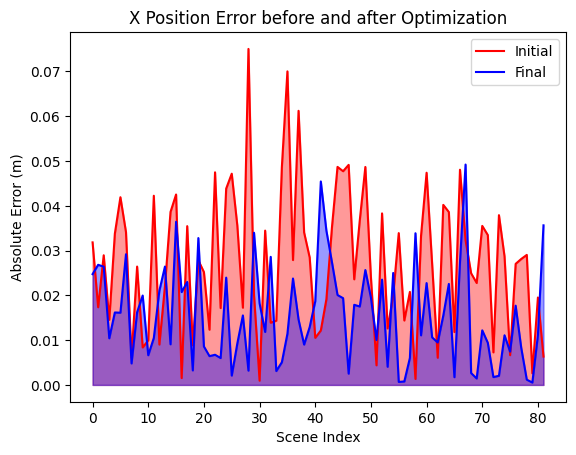

In [29]:
plt.title("X Position Error before and after Optimization")
plt.xlabel("Scene Index")
plt.ylabel("Absolute Error (m)")

plt.plot(list(range(len(good_final_x))), good_initial_x, "r", label="Initial")
plt.fill_between(list(range(len(good_initial_x))), good_initial_x, color="r", alpha=0.4)
plt.plot(list(range(len(good_final_x))), good_final_x, "b", label="Final")
plt.fill_between(list(range(len(good_final_x))), good_final_x, color="b", alpha=0.4)
plt.legend()

plt.savefig("x_position_error.png")

plt.show()

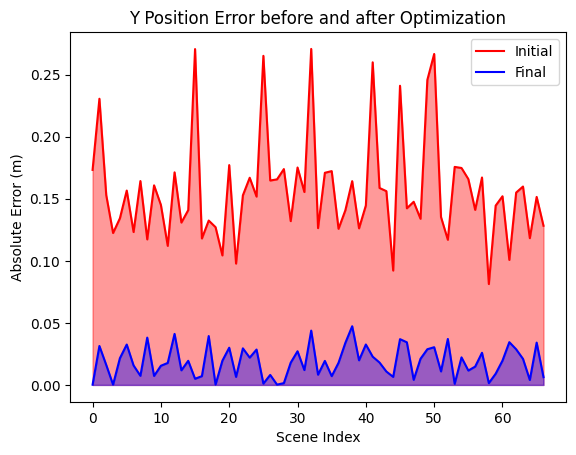

In [30]:
plt.title("Y Position Error before and after Optimization")
plt.xlabel("Scene Index")
plt.ylabel("Absolute Error (m)")

plt.plot(list(range(len(good_final_y))), good_initial_y, "r", label="Initial")
plt.fill_between(list(range(len(good_initial_y))), good_initial_y, color="r", alpha=0.4)
plt.plot(list(range(len(good_final_y))), good_final_y, "b", label="Final")
plt.fill_between(list(range(len(good_final_y))), good_final_y, color="b", alpha=0.4)
plt.legend()

plt.savefig("y_position_error.png")